# Fashion MNIST Dataset, solução para classificação de imagens

O Fashion MNIST é um conjunto de dados com 70.000 imagens de roupas em 10 categorias, usado para classificação de imagens. Neste projeto, utilizaremos redes neurais para classificar essas imagens, a ferramenta escolhida foi o TensorFlow Keras para utilizarmos durante todo o desenvolvimento do trabalho. A rede será composta por camadas densas que aprenderão a identificar padrões visuais e a mapear corretamente cada imagem para sua classe. Vamos treinar e avaliar o modelo para medir sua precisão e capacidade de generalização.

In [1]:
# Install dependencies
%pip install -r "./requirements.txt"

Note: you may need to restart the kernel to use updated packages.


In [2]:
# Chamar o arquivo das funções
from nauan.functions import *

# Import necessary libraries
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix
from tensorflow import keras
from tensorflow.keras.preprocessing.image import ImageDataGenerator # type: ignore
from tensorflow.keras import regularizers # type: ignore
from sklearn.model_selection import train_test_split
from collections import Counter

# Plotting functions for predictions
def plot_predicted_image(i, predictions_array, true_label, img):
    predictions_array, true_label, img = predictions_array[i], true_label[i], img[i]
    plt.grid(False)
    plt.xticks([])
    plt.yticks([])
    plt.imshow(img, cmap=plt.cm.binary)

    predicted_label = np.argmax(predictions_array)
    color = 'blue' if predicted_label == true_label else 'red'

    plt.xlabel(f"{class_names[predicted_label]} {100 * np.max(predictions_array):2.0f}% ({class_names[true_label]})", color=color)

def plot_value_array(i, predictions_array, true_label):
    predictions_array, true_label = predictions_array[i], true_label[i]
    plt.grid(False)
    plt.xticks(range(10))
    plt.yticks([])
    thisplot = plt.bar(range(10), predictions_array, color="#777777")
    plt.ylim([0, 1])
    predicted_label = np.argmax(predictions_array)

    thisplot[predicted_label].set_color('red')
    thisplot[true_label].set_color('blue')

# Visualize a prediction
def visualize_prediction(index, pred):
    plt.figure(figsize=(6,3))
    plt.subplot(1,2,1)
    plot_predicted_image(index, pred, test_labels, test_images)
    plt.subplot(1,2,2)
    plot_value_array(index, pred, test_labels)
    plt.show()

# Visualize multiple predictions for a specified range with a 3x3 grid layout
def visualize_predictions(indices, pred):
    plt.figure(figsize=(15, 10))  # Adjust the figure size for better spacing
    for i, index in enumerate(indices):
        plt.subplot(5, 6, 2 * i + 1)  # 5 rows, 6 columns: image on the left
        plot_predicted_image(index, pred, test_labels, test_images)
        plt.subplot(5, 6, 2 * i + 2)  # 5 rows, 6 columns: value array on the right
        plot_value_array(index, pred, test_labels)
    plt.tight_layout()
    plt.show()

print(f'TensorFlow version: {tf.__version__}')

2024-09-23 00:17:13.656026: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:485] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2024-09-23 00:17:13.669437: E external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:8454] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2024-09-23 00:17:13.673520: E external/local_xla/xla/stream_executor/cuda/cuda_blas.cc:1452] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2024-09-23 00:17:13.684962: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2024-09-23 00:17:14.501410: W tensorflow/compiler/tf2

TensorFlow version: 2.17.0


## Etapa 1: Análise dos dados

In [3]:
# Load the Fashion MNIST dataset
fashion_mnist = keras.datasets.fashion_mnist
(train_images, train_labels), (test_images, test_labels) = fashion_mnist.load_data()

# Split the training data into training and validation sets
train_images, val_images, train_labels, val_labels = train_test_split(train_images, train_labels, test_size=0.1, random_state=42, stratify=train_labels)

"""
The dataset contains 60,000 28x28 grayscale images of 10 fashion categories, along with a test set of 10,000 images.
The class names are not included with the dataset, so we will define them here to use later when plotting the images.
0- T-shirt/top
1- Trouser
2- Pullover
3- Dress
4- Coat
5- Sandal
6- Shirt
7- Sneaker
8- Bag
9- Ankle boot
"""

# Class names for the dataset
class_names = ['T-shirt/top', 'Trouser', 'Pullover', 'Dress', 'Coat', 'Sandal', 'Shirt', 'Sneaker', 'Bag', 'Ankle boot']

In [4]:
# Explore the data
print(f'Train images shape: {train_images.shape}')
print(f'Train labels shape: {train_labels.shape}')
print(f'\nValidation images shape: {val_images.shape}')
print(f'Validation labels shape: {val_labels.shape}')
print(f'\nTest images shape: {test_images.shape}')
print(f'Test labels shape: {test_labels.shape}\n')
verificar_balanceamento(train_labels)

Train images shape: (54000, 28, 28)
Train labels shape: (54000,)

Validation images shape: (6000, 28, 28)
Validation labels shape: (6000,)

Test images shape: (10000, 28, 28)
Test labels shape: (10000,)

Quantidade de amostras para cada classe:
Classe 8: 5400 amostras
Classe 9: 5400 amostras
Classe 0: 5400 amostras
Classe 1: 5400 amostras
Classe 4: 5400 amostras
Classe 6: 5400 amostras
Classe 5: 5400 amostras
Classe 7: 5400 amostras
Classe 3: 5400 amostras
Classe 2: 5400 amostras

Resumo:
Classe com menor quantidade de amostras: Classe 8 com 5400 amostras
Classe com maior quantidade de amostras: Classe 8 com 5400 amostras

O dataset está balanceado.


{8: 5400,
 9: 5400,
 0: 5400,
 1: 5400,
 4: 5400,
 6: 5400,
 5: 5400,
 7: 5400,
 3: 5400,
 2: 5400}

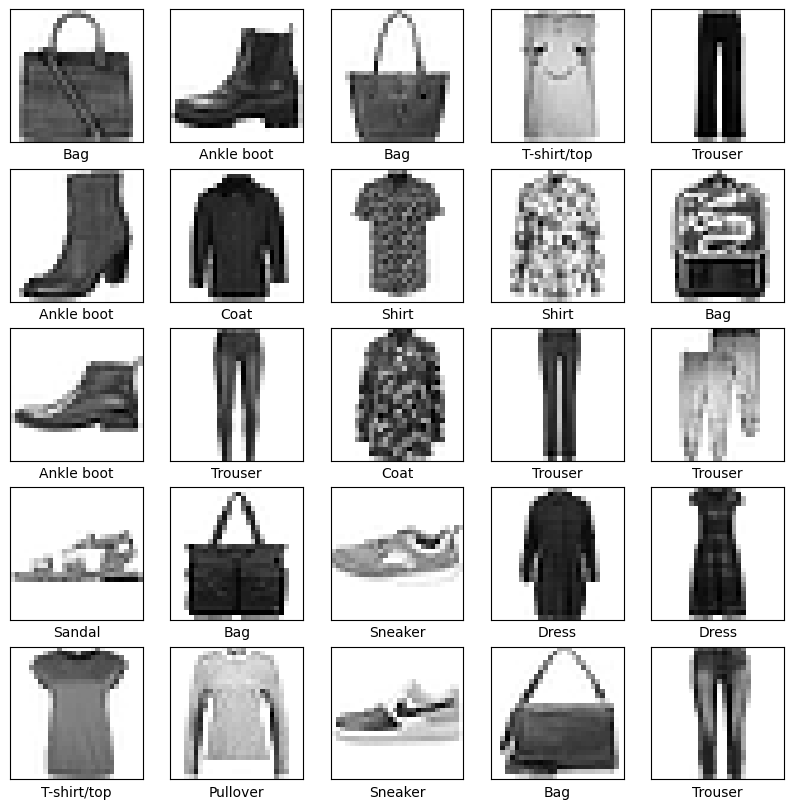

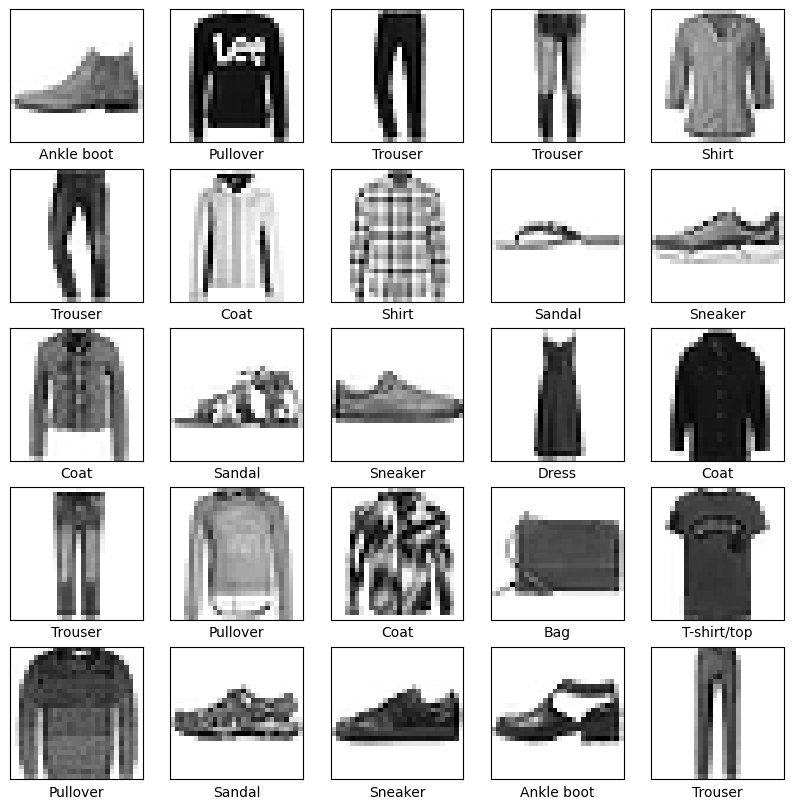

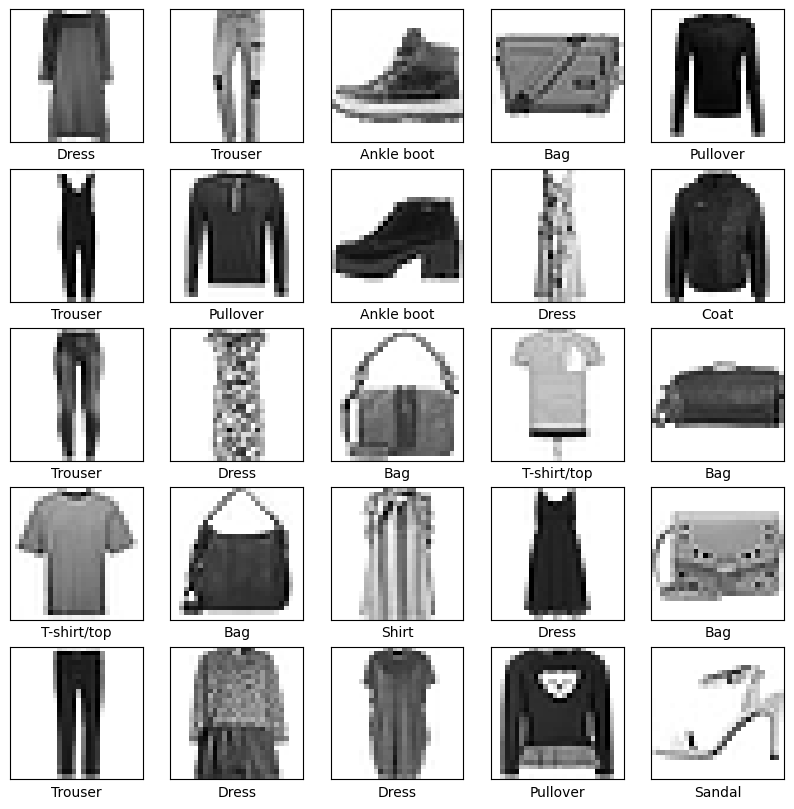

In [5]:
# Plot first 25 images of training set
plot_sample_images(train_images, train_labels, class_names)

# Plot first 25 images of test set
plot_sample_images(test_images, test_labels, class_names)

# Plot first 25 images of validation set
plot_sample_images(val_images, val_labels, class_names)

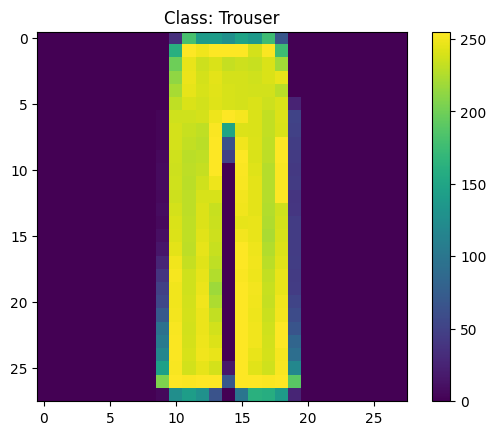

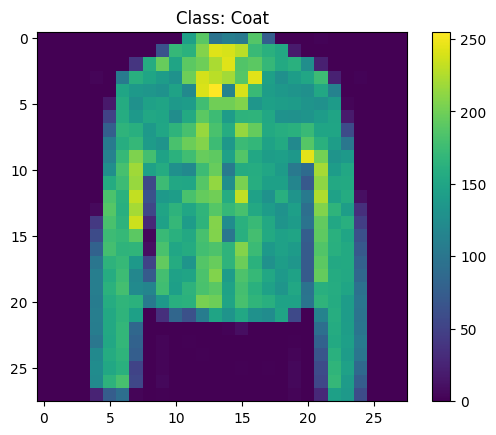

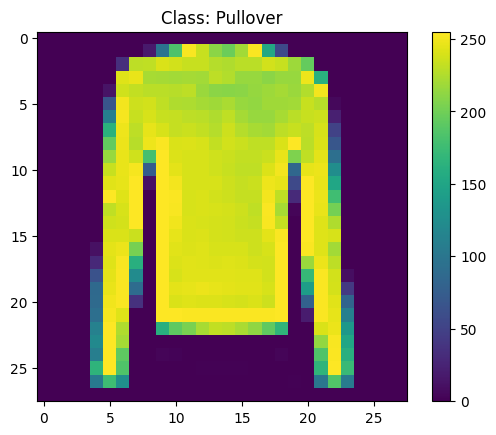

In [6]:
# Visualizar valores de imagens para verificar a necessidade de normalização
plot_image(train_images[4], train_labels[4], class_names)
plot_image(test_images[10], test_labels[10], class_names)
plot_image(val_images[4], val_labels[4], class_names)

## Etapa 2: Normalização dos dados

Acima podemos vê que as imagens estão em valores de 0 a 255 que pode causar uma pequena confusão na hora de treinar nosso modelo, logo iremos normalizá-lo para um rande de 0 a 1

In [7]:
# Data Preprocessing
train_images = preprocess_data(train_images)
test_images = preprocess_data(test_images)
val_images = preprocess_data(val_images)

# Expandir as dimensões do dataset de treinamento e de teste para utilizar DATAGEN
train_images = np.expand_dims(train_images, axis=-1)  # Adiciona a dimensão do canal
test_images = np.expand_dims(test_images, axis=-1)    # Adiciona a dimensão do canal
val_images = np.expand_dims(val_images, axis=-1)    # Adiciona a dimensão do canal

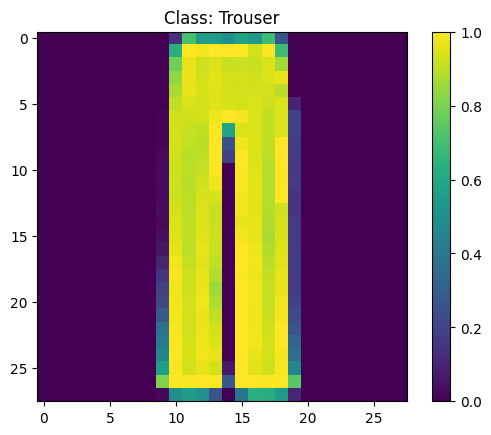

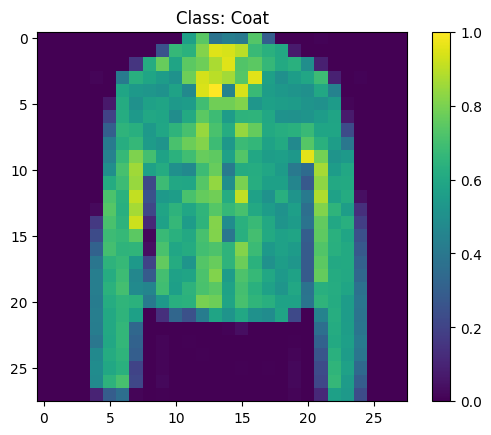

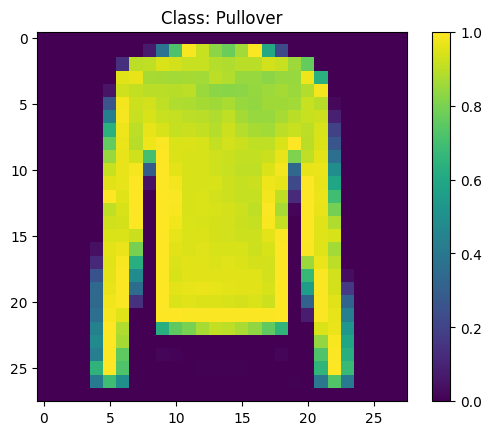

In [8]:
# Visualizar valores de imagens para verificar a necessidade de normalização
plot_image(train_images[4], train_labels[4], class_names)
plot_image(test_images[10], test_labels[10], class_names)
plot_image(val_images[4], val_labels[4], class_names)

## Etapa 3: Aplicação das técnicas de aprendizado profundo

### Etapa 3.1: Primeiro teste, parâmetros "padrões"

In [9]:
# Build the neural network model
"""
Creates and compiles a Sequential model.
Returns:
    keras.Sequential: The compiled model.
"""
model_inicial = keras.Sequential([
    keras.layers.Flatten(input_shape=(28, 28)),
    keras.layers.Dense(128, activation='relu'),
    keras.layers.Dense(10, activation='softmax')
])

"""
Função Loss -> Essa mede quão precisa o modelo é durante o treinamento. Queremos minimizar a função para guiar o modelo para a direção certa.
Optimizer -> Isso é como o modelo se atualiza com base no dado que ele vê e sua função loss.
Métricas -> usadas para monitorar os passos de treinamento e teste. O exemplo abaixo usa a acurácia, a fração das imagens que foram classificadas corretamente.
"""
model_inicial.compile(optimizer='adam',
                      loss='sparse_categorical_crossentropy',
                      metrics=['accuracy'])

/home/zeus/miniconda3/envs/cloudspace/lib/python3.10/site-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)
2024-09-23 00:17:19.056156: I tensorflow/core/common_runtime/gpu/gpu_device.cc:2021] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 20974 MB memory:  -> device: 0, name: NVIDIA L4, pci bus id: 0000:35:00.0, compute capability: 8.9


In [10]:
# Train the model
history_model_inicial = train_model(model_inicial, train_images, train_labels, val_images, val_labels, file_path='model_inicial.keras')

Epoch 1/200


I0000 00:00:1727050640.498737   36376 service.cc:146] XLA service 0x7fddb0008c50 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1727050640.498769   36376 service.cc:154]   StreamExecutor device (0): NVIDIA L4, Compute Capability 8.9
2024-09-23 00:17:20.511579: I tensorflow/compiler/mlir/tensorflow/utils/dump_mlir_util.cc:268] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
2024-09-23 00:17:20.573228: I external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:531] Loaded cuDNN version 8902


 187/1688 ━━━━━━━━━━━━━━━━━━━━ 1s 815us/step - accuracy: 0.6440 - loss: 1.0776

I0000 00:00:1727050641.502341   36376 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


1688/1688 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.7796 - loss: 0.6408  
Epoch 1: val_loss improved from inf to 0.38768, saving model to model_inicial.keras
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.7796 - loss: 0.6407 - val_accuracy: 0.8665 - val_loss: 0.3877
Epoch 2/200
1672/1688 ━━━━━━━━━━━━━━━━━━━━ 0s 723us/step - accuracy: 0.8605 - loss: 0.3881
Epoch 2: val_loss improved from 0.38768 to 0.36076, saving model to model_inicial.keras
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 1s 813us/step - accuracy: 0.8605 - loss: 0.3881 - val_accuracy: 0.8702 - val_loss: 0.3608
Epoch 3/200
1674/1688 ━━━━━━━━━━━━━━━━━━━━ 0s 782us/step - accuracy: 0.8738 - loss: 0.3481
Epoch 3: val_loss improved from 0.36076 to 0.31739, saving model to model_inicial.keras
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 2s 883us/step - accuracy: 0.8738 - loss: 0.3481 - val_accuracy: 0.8855 - val_loss: 0.3174
Epoch 4/200
1623/1688 ━━━━━━━━━━━━━━━━━━━━ 0s 745us/step - accuracy: 0.8876 - loss: 0.3115
Epoch 4: val_loss improved 

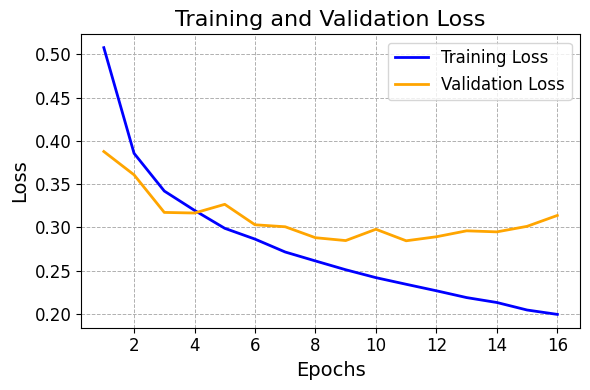

313/313 - 0s - 682us/step - accuracy: 0.8830 - loss: 0.3360


[0.3360246419906616, 0.8830000162124634]

In [11]:
# Plotagem do gráfico de perda
plot_loss(model_inicial.history)

# Teste de acurácia com as amostras de teste
model_inicial.evaluate(test_images, test_labels, verbose=2)

  1/313 ━━━━━━━━━━━━━━━━━━━━ 56s 180ms/step

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step


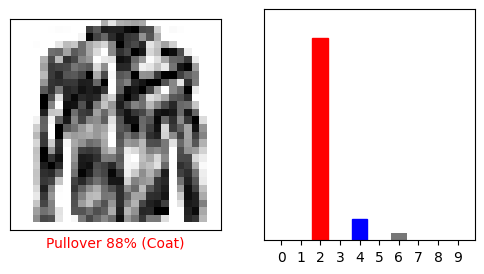

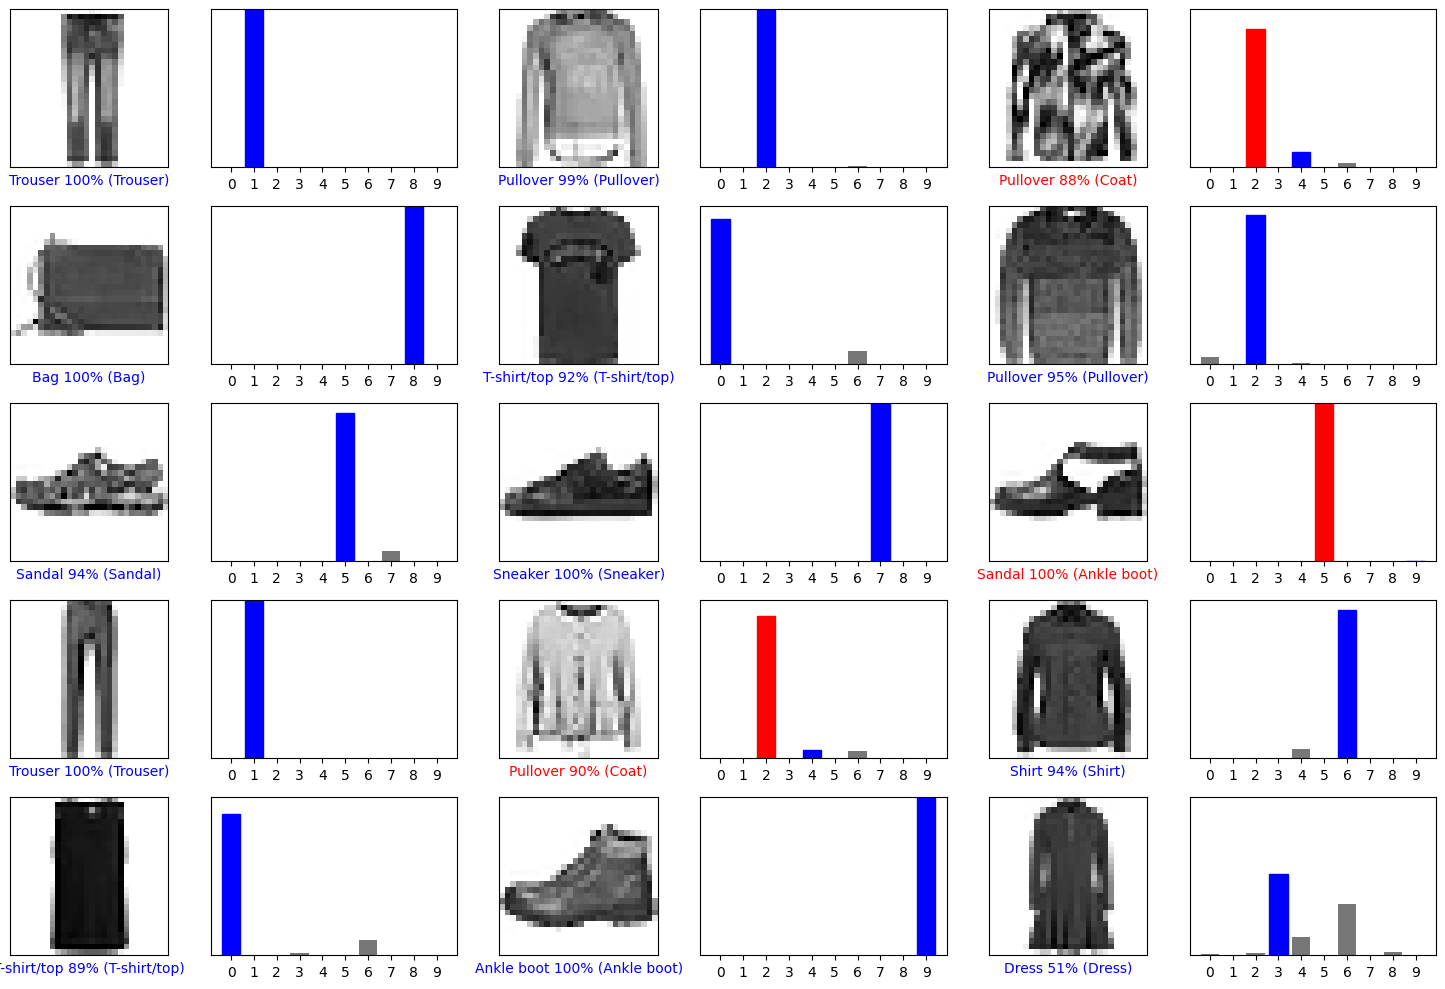

313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 616us/step


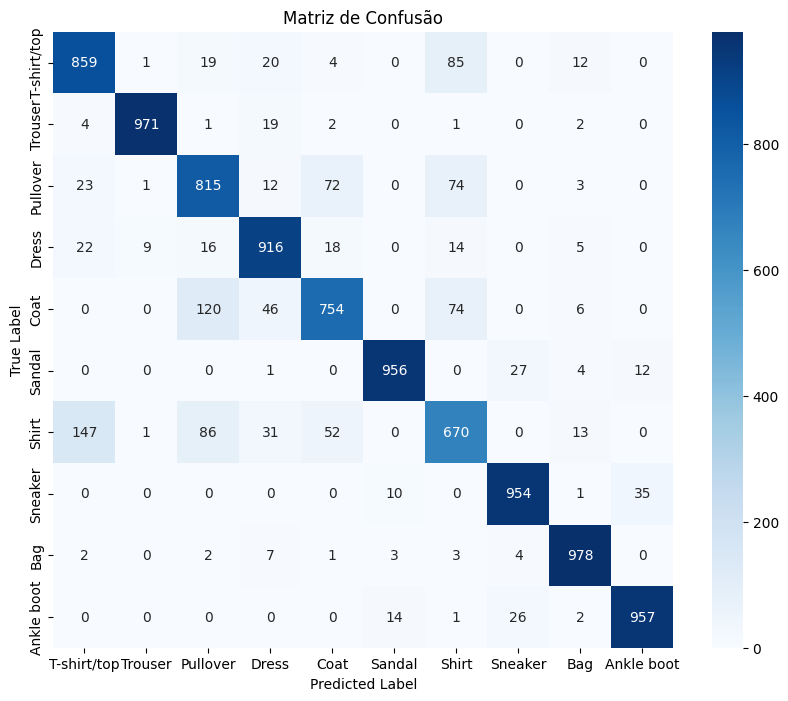

In [12]:
# Make predictions
predictions1 = model_inicial.predict(test_images)

# Visualize a specific prediction
visualize_prediction(17, predictions1)

# Visualize 15 specific predictions
visualize_predictions(range(15, 30), predictions1)

# Chamando a função para plotar a matriz de confusão
plot_confusion_matrix(model_inicial, test_images, test_labels, class_names)

### Etapa 3.2: Teste com camadas convolucionais

No primeiro teste é observado um pequeno overfitting tanto pela comparação da acurácia com teste e na visualização das imagens é possível também perceber isto.
<br>Normalmente o teste com camadas convolucionais tende a ser promissor e sempre perfoma acurácias muito boas.

In [46]:
# Build the neural network model
"""
Creates and compiles a Sequential model.
Returns:
    keras.Sequential: The compiled model.
"""
model_teste2 = tf.keras.Sequential([
    tf.keras.layers.Conv2D(32, (3, 3), activation='relu', input_shape=(28, 28, 1)),
    tf.keras.layers.MaxPooling2D((2, 2)),
    tf.keras.layers.Conv2D(64, (3, 3), activation='relu'),
    tf.keras.layers.MaxPooling2D((2, 2)),
    tf.keras.layers.Conv2D(128, (3, 3), activation='relu'),
    tf.keras.layers.Flatten(),
    tf.keras.layers.Dense(128, activation='relu'),
    tf.keras.layers.Dense(10, activation='softmax')
])

model_teste2.compile(optimizer='adam',
                  loss='sparse_categorical_crossentropy',
                  metrics=['accuracy'])

/home/zeus/miniconda3/envs/cloudspace/lib/python3.10/site-packages/keras/src/layers/convolutional/base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [47]:
# Train the model
history_model_teste2 = train_model(model_teste2, train_images, train_labels, val_images, val_labels, file_path='model_teste2.keras')

Epoch 1/200
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.7479 - loss: 0.6811
Epoch 1: val_loss improved from inf to 0.32564, saving model to model_teste2.keras
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 5s 2ms/step - accuracy: 0.7479 - loss: 0.6810 - val_accuracy: 0.8847 - val_loss: 0.3256
Epoch 2/200
1676/1688 ━━━━━━━━━━━━━━━━━━━━ 0s 994us/step - accuracy: 0.8790 - loss: 0.3275
Epoch 2: val_loss improved from 0.32564 to 0.27394, saving model to model_teste2.keras
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.8790 - loss: 0.3274 - val_accuracy: 0.9020 - val_loss: 0.2739
Epoch 3/200
1643/1688 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.8998 - loss: 0.2699
Epoch 3: val_loss improved from 0.27394 to 0.25103, saving model to model_teste2.keras
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.8998 - loss: 0.2699 - val_accuracy: 0.9092 - val_loss: 0.2510
Epoch 4/200
1684/1688 ━━━━━━━━━━━━━━━━━━━━ 0s 989us/step - accuracy: 0.9120 - loss: 0.2388
Epoch 4: val_loss did not 

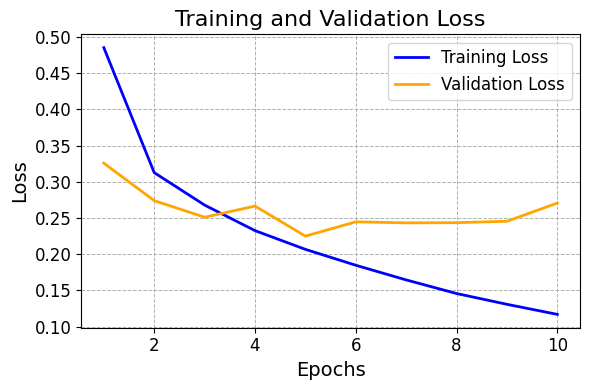

313/313 - 0s - 762us/step - accuracy: 0.9101 - loss: 0.2547


[0.25466734170913696, 0.910099983215332]

In [48]:
# Plotagem do gráfico de perda
plot_loss(model_teste2.history)

# Teste de acurácia com as amostras de teste
model_teste2.evaluate(test_images, test_labels, verbose=2)

In [16]:
model_teste2.evaluate(val_images, val_labels, verbose=2)

188/188 - 1s - 5ms/step - accuracy: 0.9200 - loss: 0.2249


[0.22492580115795135, 0.9200000166893005]

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step


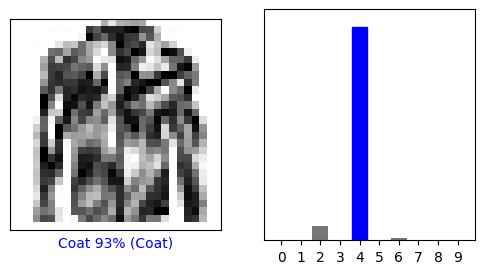

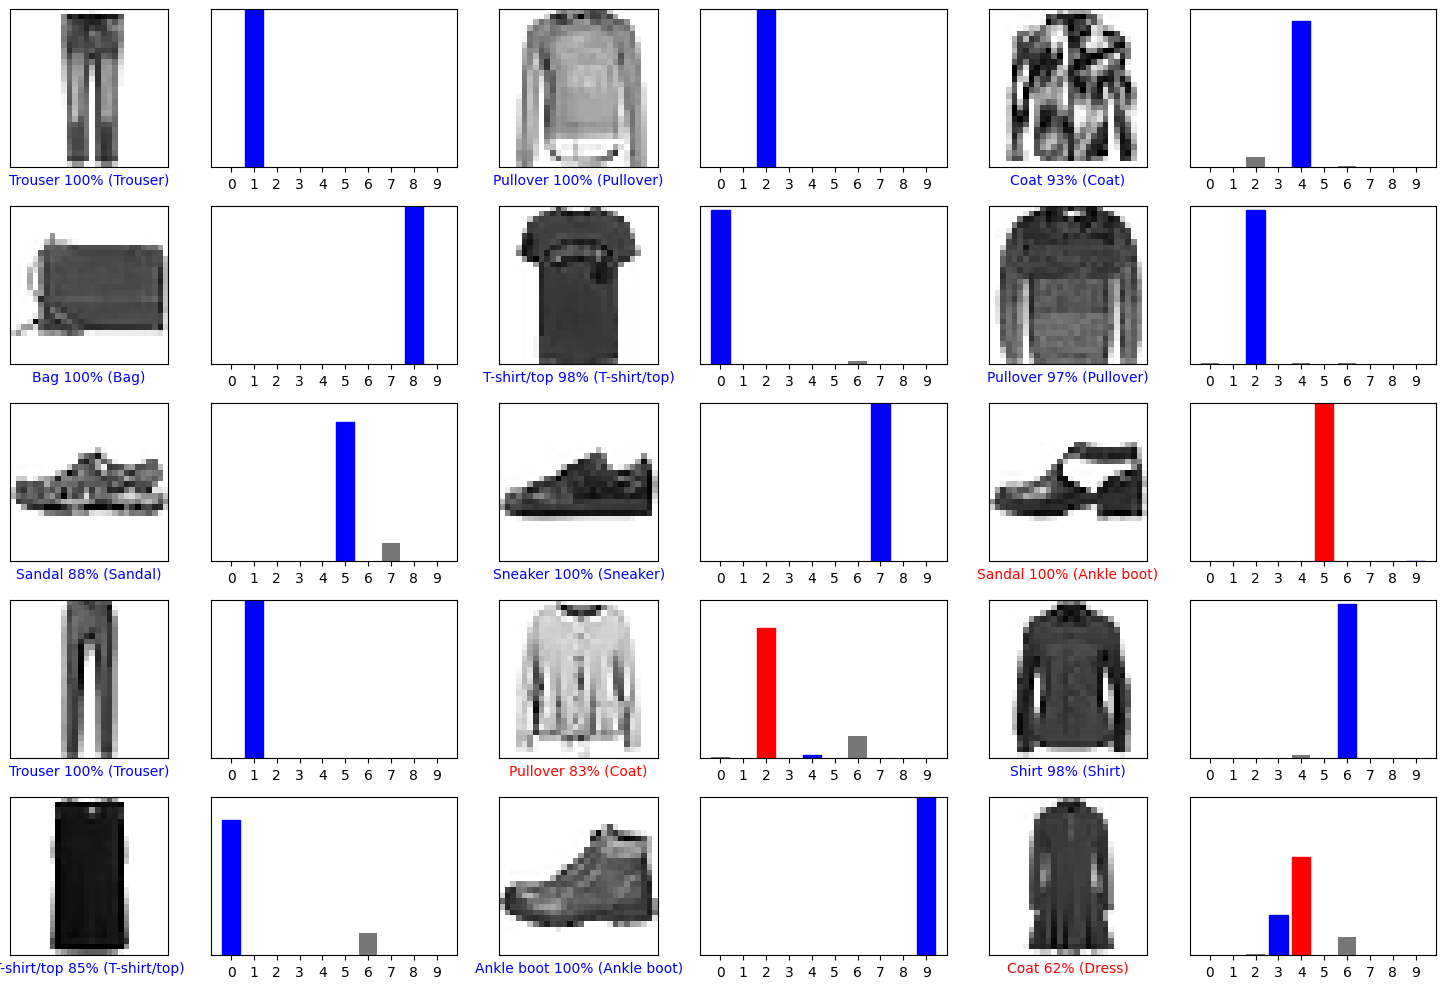

313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 679us/step


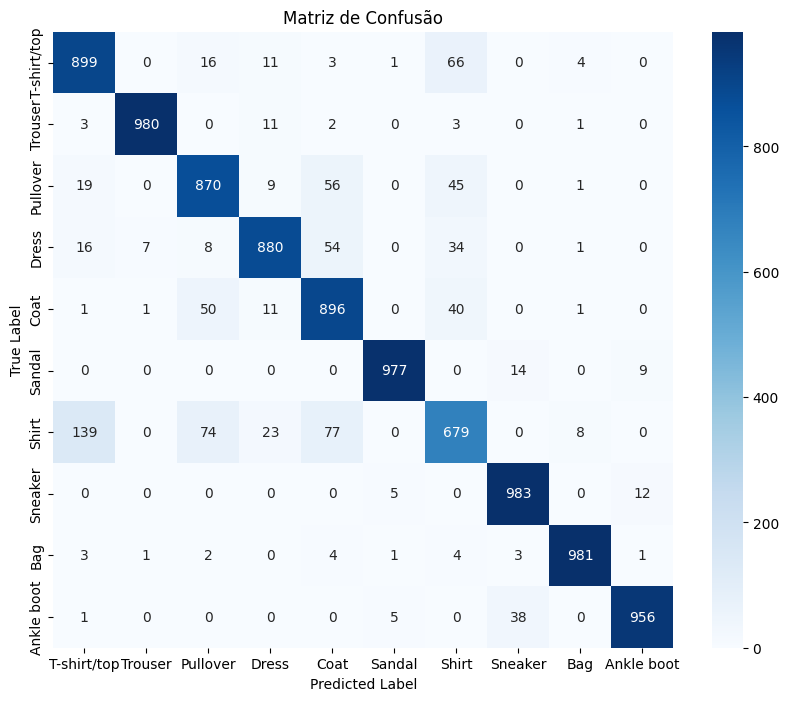

In [15]:
# Make predictions
predictions2 = model_teste2.predict(test_images)

# Visualize a specific prediction
visualize_prediction(17, predictions2)

# Visualize 15 specific predictions
visualize_predictions(range(15, 30), predictions2)

# Chamando a função para plotar a matriz de confusão
plot_confusion_matrix(model_teste2, test_images, test_labels, class_names)

### Etapa 3.3: Teste com uso do otimizador SGD com momentum

Tivemos otimos resultados com as rede convolucionais, porém cabe o teste com outro otimizador

In [51]:
# Build the neural network model
"""
Creates and compiles a Sequential model.
Returns:
    keras.Sequential: The compiled model.
"""
model_teste3 = tf.keras.Sequential([
    tf.keras.layers.Conv2D(32, (3, 3), activation='relu', input_shape=(28, 28, 1)),
    tf.keras.layers.MaxPooling2D((2, 2)),
    tf.keras.layers.Conv2D(64, (3, 3), activation='relu'),
    tf.keras.layers.MaxPooling2D((2, 2)),
    tf.keras.layers.Conv2D(128, (3, 3), activation='relu'),
    tf.keras.layers.Flatten(),
    tf.keras.layers.Dense(128, activation='relu'),
    tf.keras.layers.Dense(10, activation='softmax')
])

"""
Função Loss -> Utiliza sparse_categorical_crossentropy para tarefas de classificação com rótulos inteiros.
Optimizer -> Adam é um otimizador eficiente para redes neurais.
Métricas -> Accuracy é usada para monitorar o desempenho da classificação.
"""
model_teste3.compile(optimizer=tf.keras.optimizers.SGD(learning_rate=0.01, momentum=0.9),
                   loss='sparse_categorical_crossentropy',
                   metrics=['accuracy'])

In [52]:
# Train the model
history_model_teste3 = train_model(model_teste3, train_images, train_labels, val_images, val_labels, file_path='model_teste3.keras')

Epoch 1/200
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.6813 - loss: 0.8930
Epoch 1: val_loss improved from inf to 0.37533, saving model to model_teste3.keras
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.6813 - loss: 0.8928 - val_accuracy: 0.8662 - val_loss: 0.3753
Epoch 2/200
1671/1688 ━━━━━━━━━━━━━━━━━━━━ 0s 937us/step - accuracy: 0.8597 - loss: 0.3792
Epoch 2: val_loss improved from 0.37533 to 0.31822, saving model to model_teste3.keras
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.8597 - loss: 0.3790 - val_accuracy: 0.8860 - val_loss: 0.3182
Epoch 3/200
1683/1688 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.8863 - loss: 0.3093
Epoch 3: val_loss improved from 0.31822 to 0.30895, saving model to model_teste3.keras
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.8863 - loss: 0.3093 - val_accuracy: 0.8865 - val_loss: 0.3090
Epoch 4/200
1648/1688 ━━━━━━━━━━━━━━━━━━━━ 0s 949us/step - accuracy: 0.8945 - loss: 0.2855
Epoch 4: val_loss improved

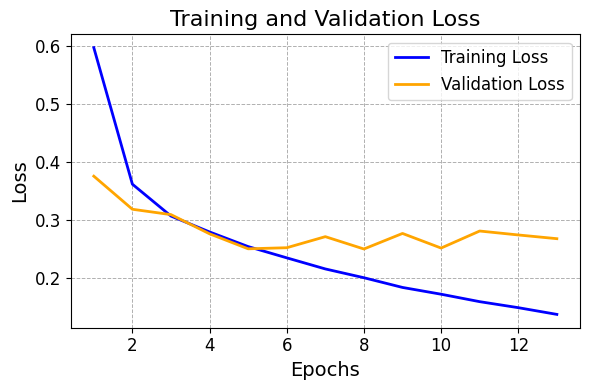

313/313 - 0s - 769us/step - accuracy: 0.9020 - loss: 0.2737


[0.2736988663673401, 0.9020000100135803]

In [53]:
# Plotagem do gráfico de perda
plot_loss(model_teste3.history)

# Teste de acurácia com as amostras de teste
model_teste3.evaluate(test_images, test_labels, verbose=2)

In [18]:
model_teste3 = keras.models.load_model('model_teste3.keras')
model_teste3.load_weights('model_teste3.keras')

  1/313 ━━━━━━━━━━━━━━━━━━━━ 51s 164ms/step

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step


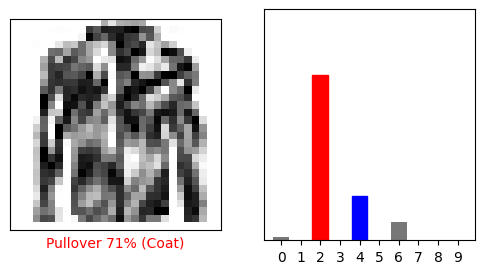

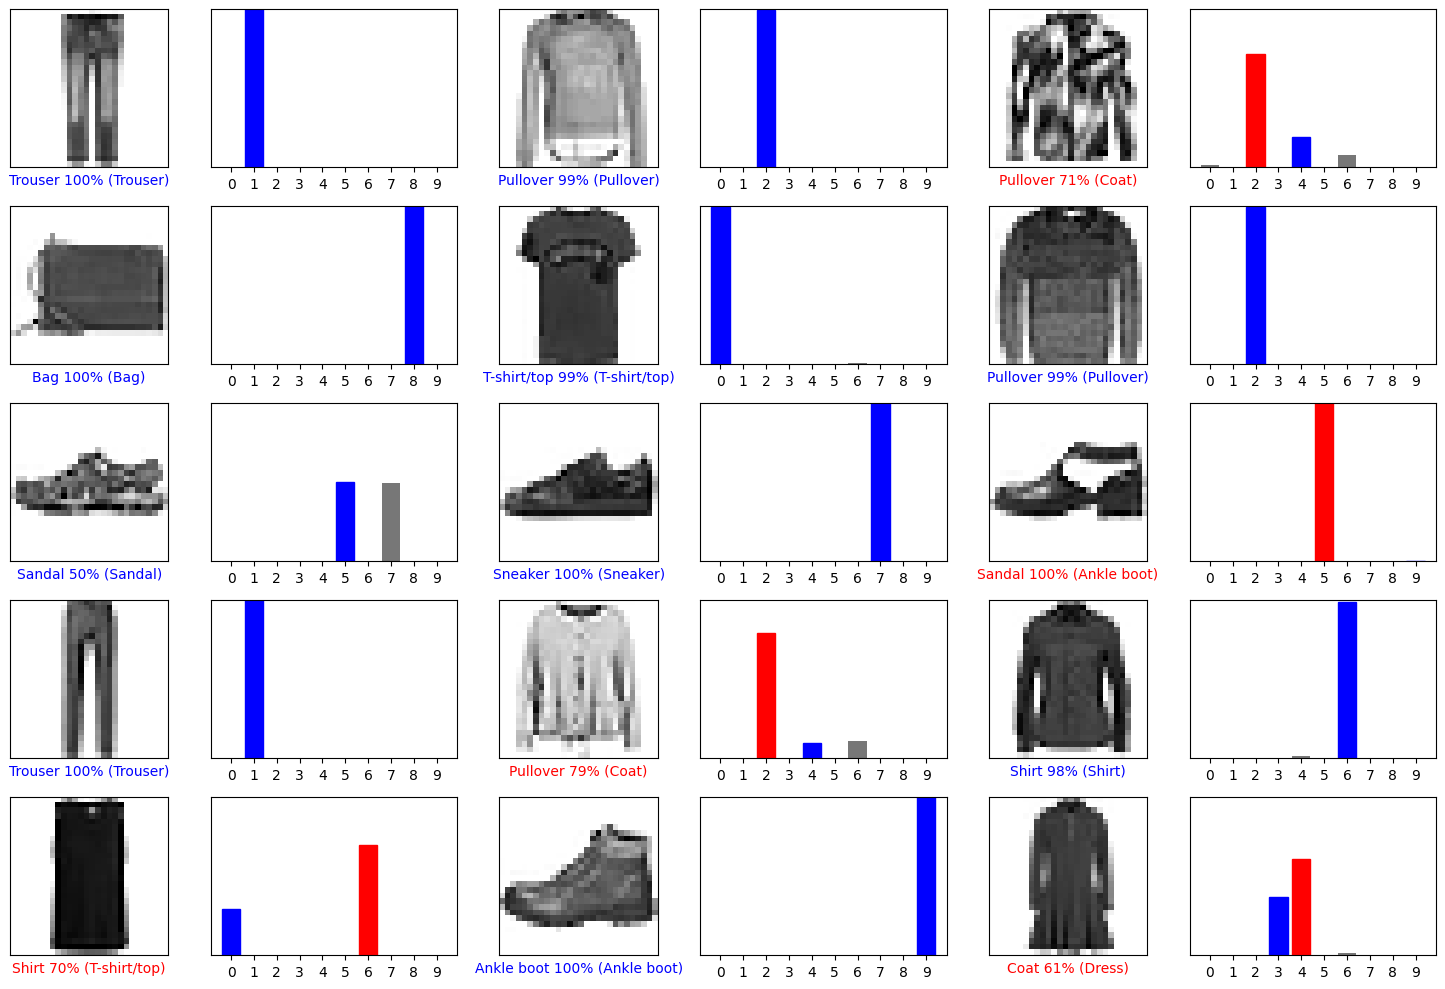

313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 773us/step


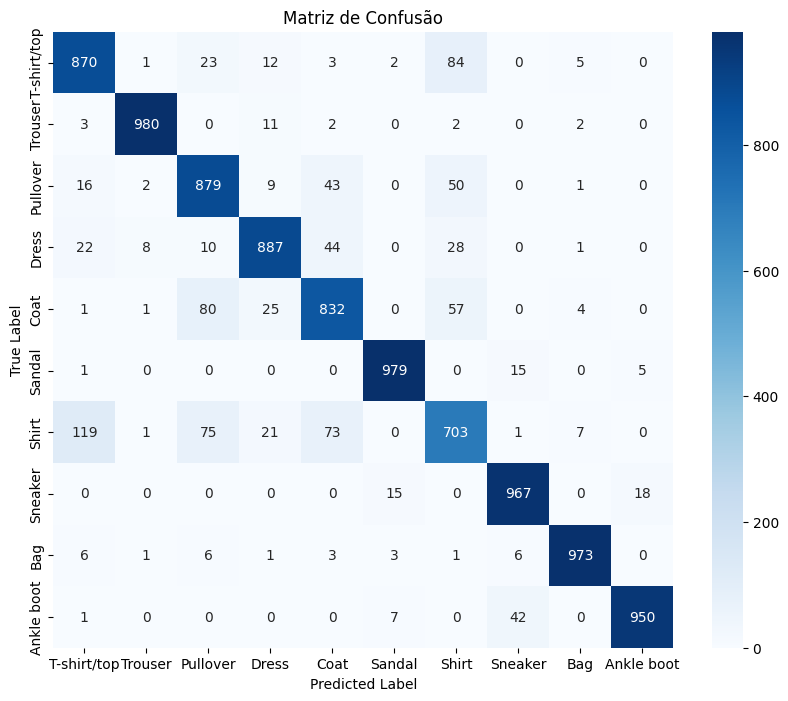

In [19]:
# Make predictions
predictions3 = model_teste3.predict(test_images)

# Visualize a specific prediction
visualize_prediction(17, predictions3)

# Visualize 15 specific predictions
visualize_predictions(range(15, 30), predictions3)

# Chamando a função para plotar a matriz de confusão
plot_confusion_matrix(model_teste3, test_images, test_labels, class_names)

### Etapa 3.4: Teste FINAL voltando ao otimizador ADAM com data augmentation

O Overfitting foi reduzindo a cada etapa, mas agora é hora de acabar de vez, mas será que os resultados ainda permanecerão interessantes?

In [59]:
# Build the neural network model
"""
Creates and compiles a Sequential model.
Returns:
    keras.Sequential: The compiled model.
"""
model_final = tf.keras.Sequential([
    tf.keras.layers.Conv2D(32, (3, 3), activation='relu', input_shape=(28, 28, 1)),
    tf.keras.layers.MaxPooling2D((2, 2)),
    tf.keras.layers.Conv2D(64, (3, 3), activation='relu'),
    tf.keras.layers.MaxPooling2D((2, 2)),
    tf.keras.layers.Conv2D(128, (3, 3), activation='relu'),
    tf.keras.layers.Flatten(),
    tf.keras.layers.Dense(128, activation='relu'),
    tf.keras.layers.Dense(10, activation='softmax')
])

model_final.compile(optimizer='adam',
                  loss='sparse_categorical_crossentropy',
                  metrics=['accuracy'])

/home/zeus/miniconda3/envs/cloudspace/lib/python3.10/site-packages/keras/src/layers/convolutional/base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [60]:
# Train the model
history_model_final = train_model(model_final, train_images, train_labels, val_images, val_labels, file_path='model_final.keras', data_aug=True)

Epoch 1/200


/home/zeus/miniconda3/envs/cloudspace/lib/python3.10/site-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:122: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


1680/1688 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.5808 - loss: 1.1183
Epoch 1: val_loss improved from inf to 0.54502, saving model to model_final.keras
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 13s 7ms/step - accuracy: 0.5813 - loss: 1.1170 - val_accuracy: 0.7970 - val_loss: 0.5450
Epoch 2/200
1678/1688 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.7468 - loss: 0.6648
Epoch 2: val_loss improved from 0.54502 to 0.44667, saving model to model_final.keras
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 10s 6ms/step - accuracy: 0.7468 - loss: 0.6646 - val_accuracy: 0.8323 - val_loss: 0.4467
Epoch 3/200
1675/1688 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.7840 - loss: 0.5775
Epoch 3: val_loss improved from 0.44667 to 0.40192, saving model to model_final.keras
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 10s 6ms/step - accuracy: 0.7840 - loss: 0.5774 - val_accuracy: 0.8508 - val_loss: 0.4019
Epoch 4/200
1676/1688 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.7994 - loss: 0.5324
Epoch 4: val_loss improved from 0.40192 to

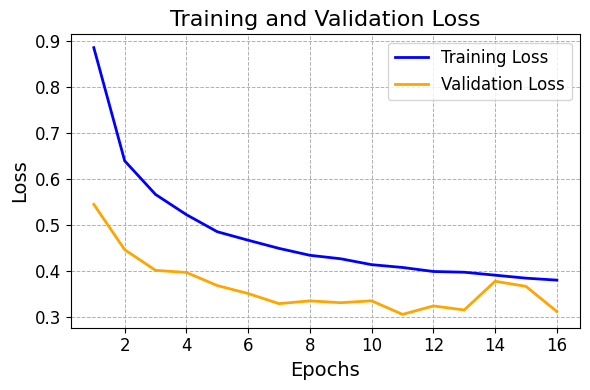

313/313 - 0s - 750us/step - accuracy: 0.8780 - loss: 0.3384


[0.33844566345214844, 0.878000020980835]

In [61]:
# Plotagem do gráfico de perda
plot_loss(model_final.history)

# Teste de acurácia com as amostras de teste
model_final.evaluate(test_images, test_labels, verbose=2)

In [62]:
model_final.evaluate(val_images, val_labels, verbose=2)

188/188 - 0s - 792us/step - accuracy: 0.8862 - loss: 0.3064


[0.3064029812812805, 0.8861666917800903]

  1/313 ━━━━━━━━━━━━━━━━━━━━ 51s 164ms/step

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step


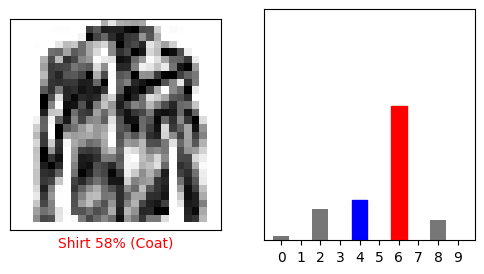

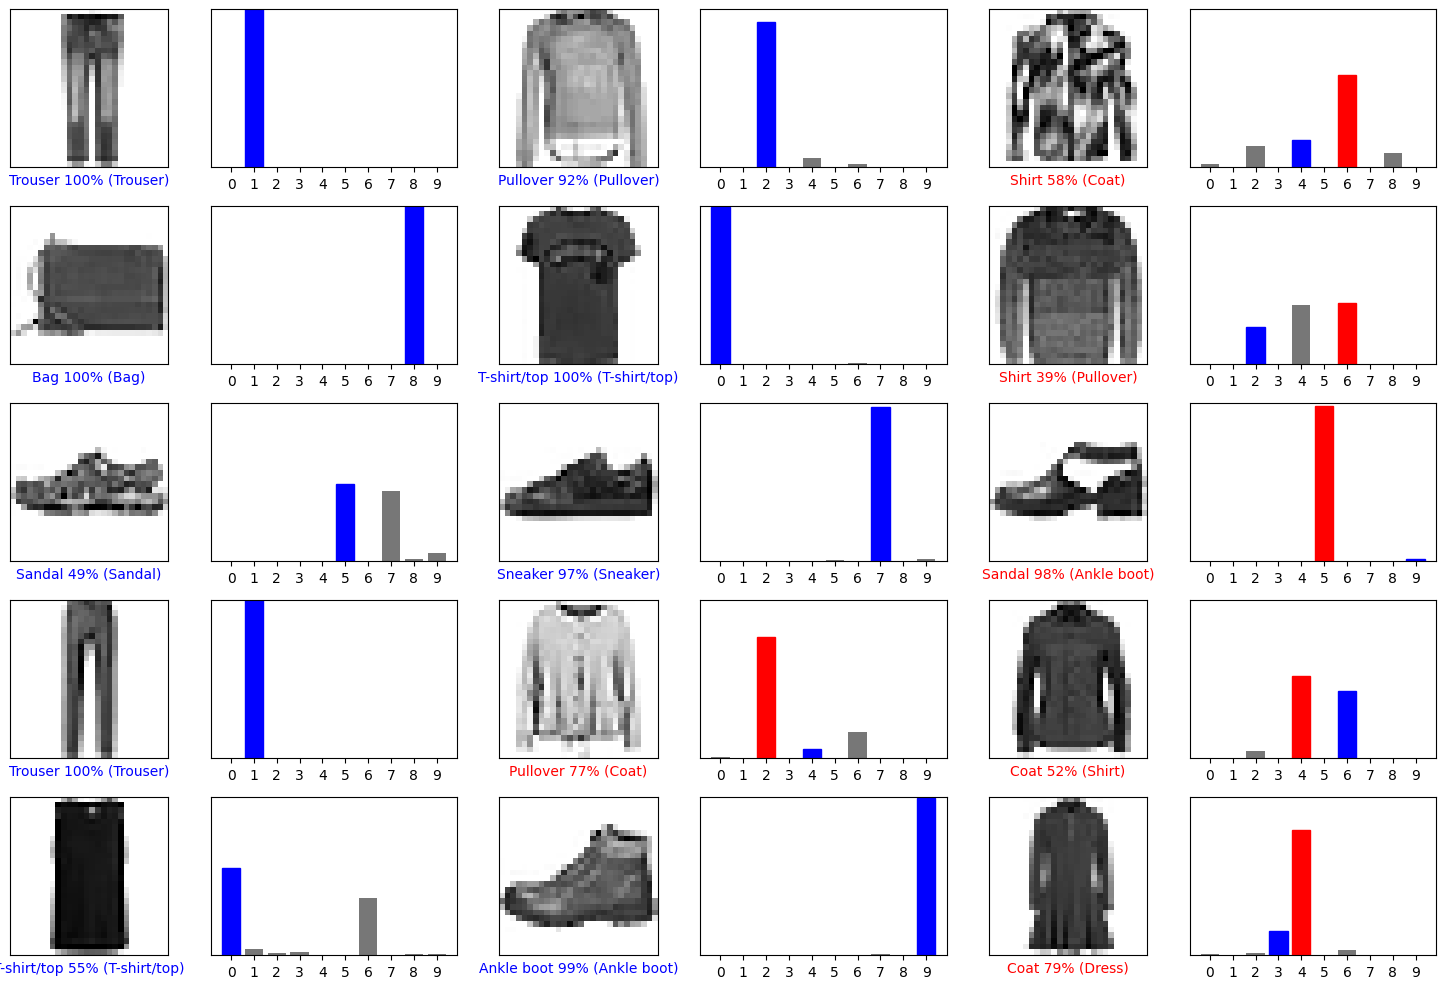

313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 690us/step


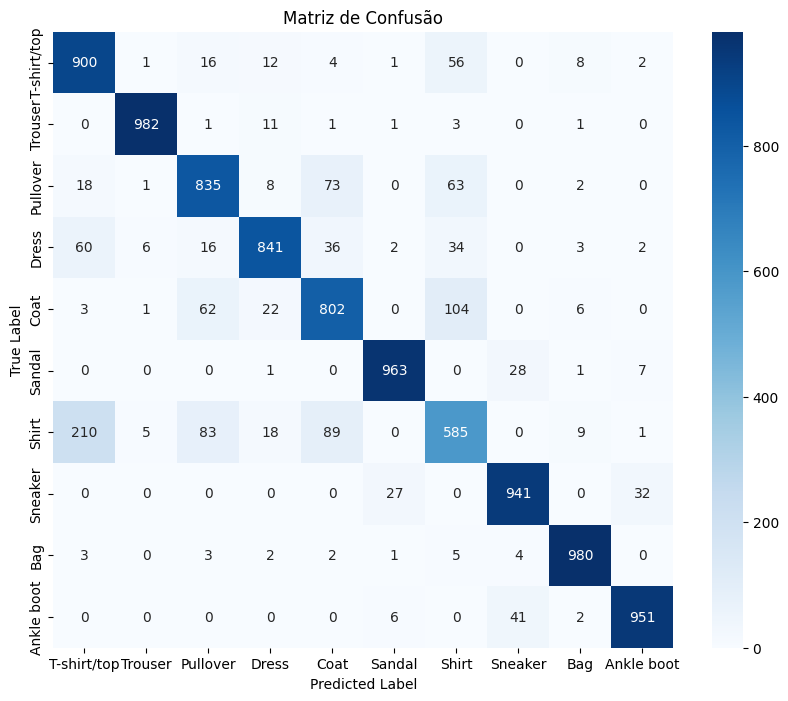

In [21]:
# Make predictions
predictions4 = model_final.predict(test_images)

# Visualize a specific prediction
visualize_prediction(17, predictions4)

# Visualize 15 specific predictions
visualize_predictions(range(15, 30), predictions4)

# Chamando a função para plotar a matriz de confusão
plot_confusion_matrix(model_final, test_images, test_labels, class_names)

## Breakpoint: Carregar modelo sem necessidade de treinamento

In [55]:
"""
model_inicial = keras.models.load_model('model_inicial.keras')
model_inicial.load_weights('model_inicial.keras')

model_teste2 = keras.models.load_model('model_teste2.keras')
model_teste2.load_weights('model_teste2.keras')

model_teste3 = keras.models.load_model('model_teste3.keras')
model_teste3.load_weights('model_teste3.keras')

model_final = keras.models.load_model('model_final.keras')
model_teste3.load_weights('model_final.keras')
"""

"\nmodel_inicial = keras.models.load_model('model_inicial.keras')\nmodel_inicial.load_weights('model_inicial.keras')\n\nmodel_teste2 = keras.models.load_model('model_teste2.keras')\nmodel_teste2.load_weights('model_teste2.keras')\n\nmodel_teste3 = keras.models.load_model('model_teste3.keras')\nmodel_teste3.load_weights('model_teste3.keras')\n"

## Etapa 4: Análise das predições e resultados

In [56]:
"""
# Make predictions
predictions1 = model_inicial.predict(test_images)
predictions2 = model_teste2.predict(test_images)
predictions3 = model_teste3.predict(test_images)
predictions4 = model_teste4.predict(test_images)
"""

'\n# Make predictions\npredictions1 = model_inicial.predict(test_images)\npredictions2 = model_teste2.predict(test_images)\npredictions3 = model_teste3.predict(test_images)\npredictions4 = model_teste4.predict(test_images)\n'

### Resultados Numéricos:
1. Rede padrão ->
<br>no treino -> accuracy: 0.9113 - loss: 0.2359 - val_accuracy: 0.8992 - val_loss: 0.2847
<br>no teste -> accuracy: 0.8830 - loss: 0.3360
2. Rede conv. otimizador padrão:
<br>no treino: accuracy: 0.9240 - loss: 0.2048 - val_accuracy: 0.9200 - val_loss: 0.2249
<br>no teste -> accuracy: 0.9200 - loss: 0.2249
3. Rede conv. otimizador SGD:
<br>no treino -> accuracy: 0.9248 - loss: 0.1981 - val_accuracy: 0.9110 - val_loss: 0.2496
<br>no teste -> accuracy: 0.9020 - loss: 0.2737
4. Rede conv. otimizador padrão com data augmentation ->
<br>no treino -> accuracy: 0.8458 - loss: 0.4104 - val_accuracy: 0.8862 - val_loss: 0.3064
<br>no teste -> accuracy: 0.8862 - loss: 0.3064

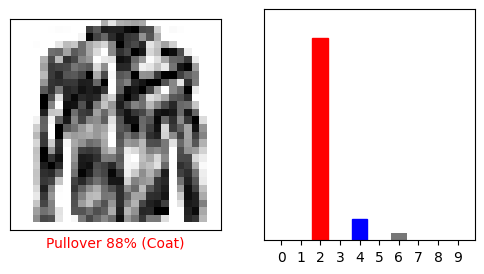

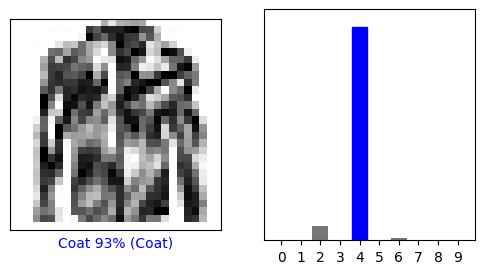

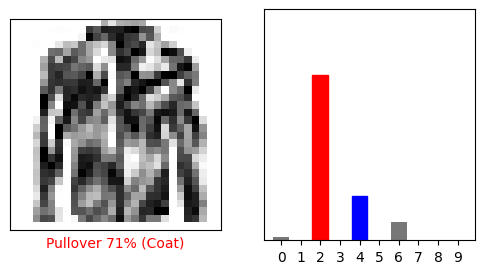

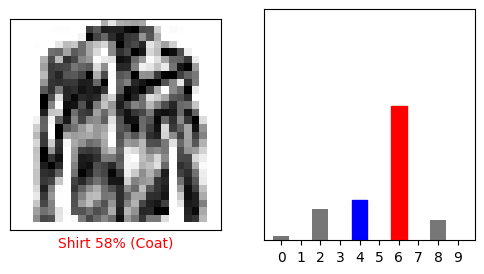

In [22]:
# Visualize a specific prediction
visualize_prediction(17, predictions1)
visualize_prediction(17, predictions2)
visualize_prediction(17, predictions3)
visualize_prediction(17, predictions4)

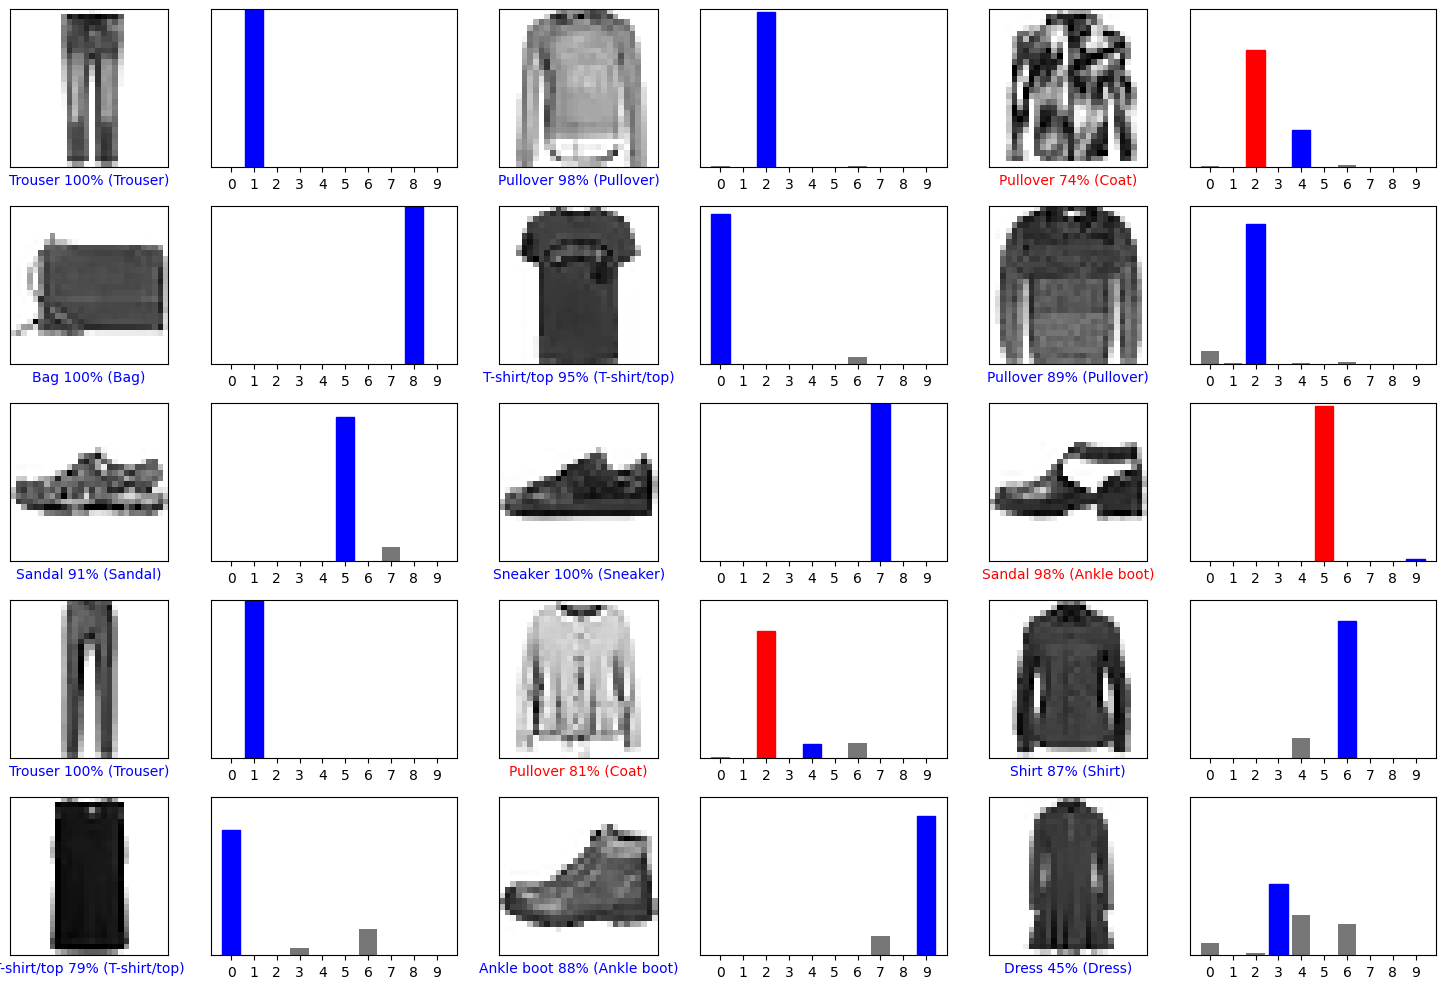

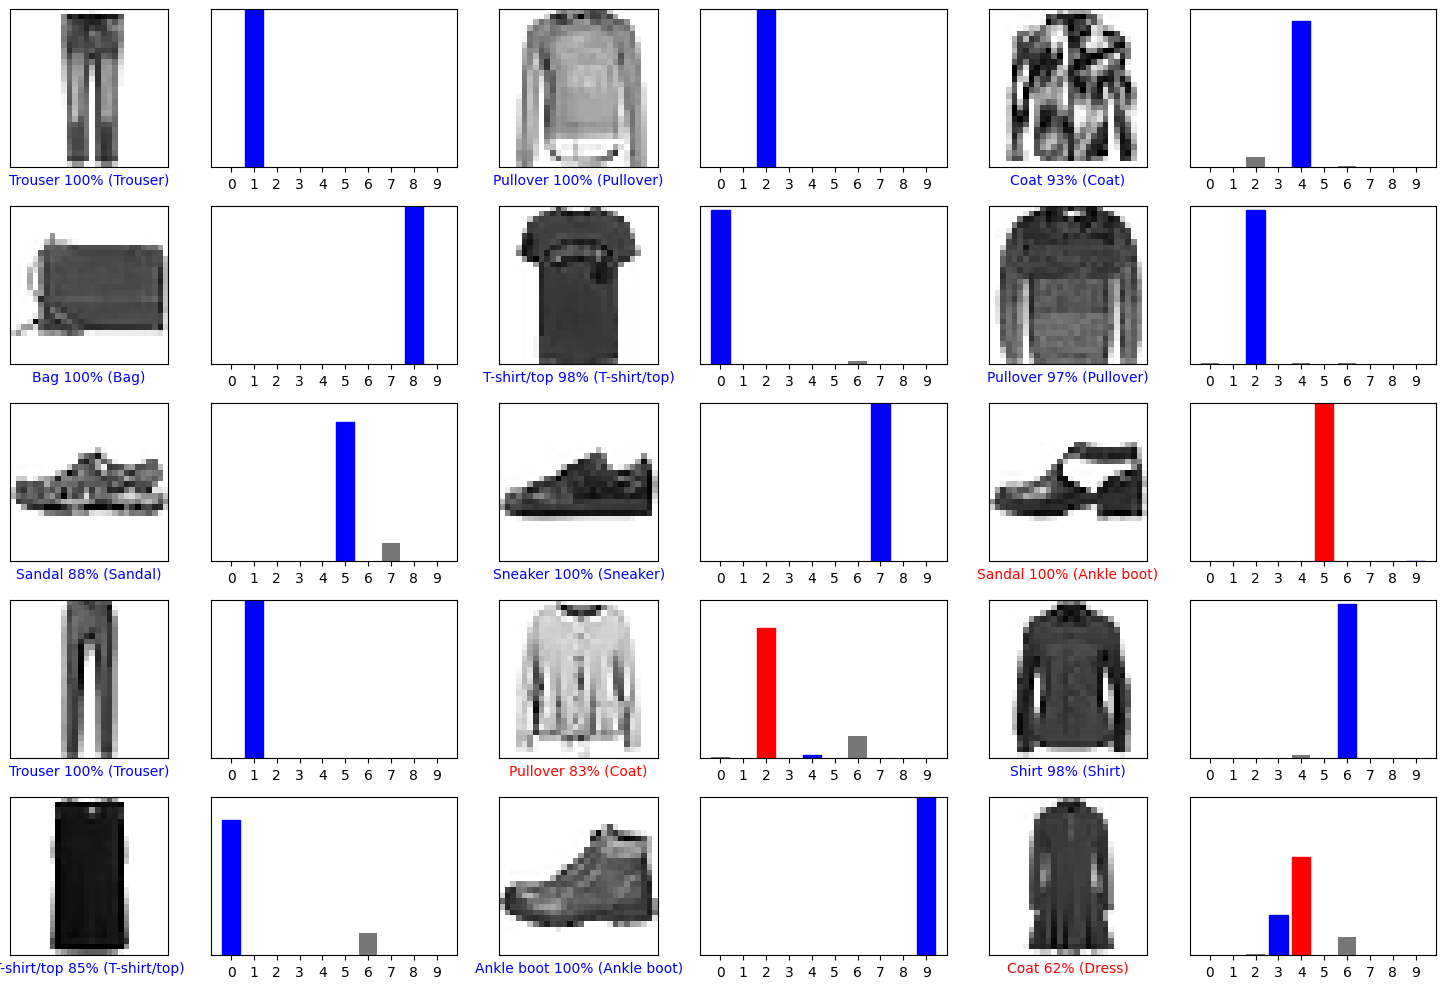

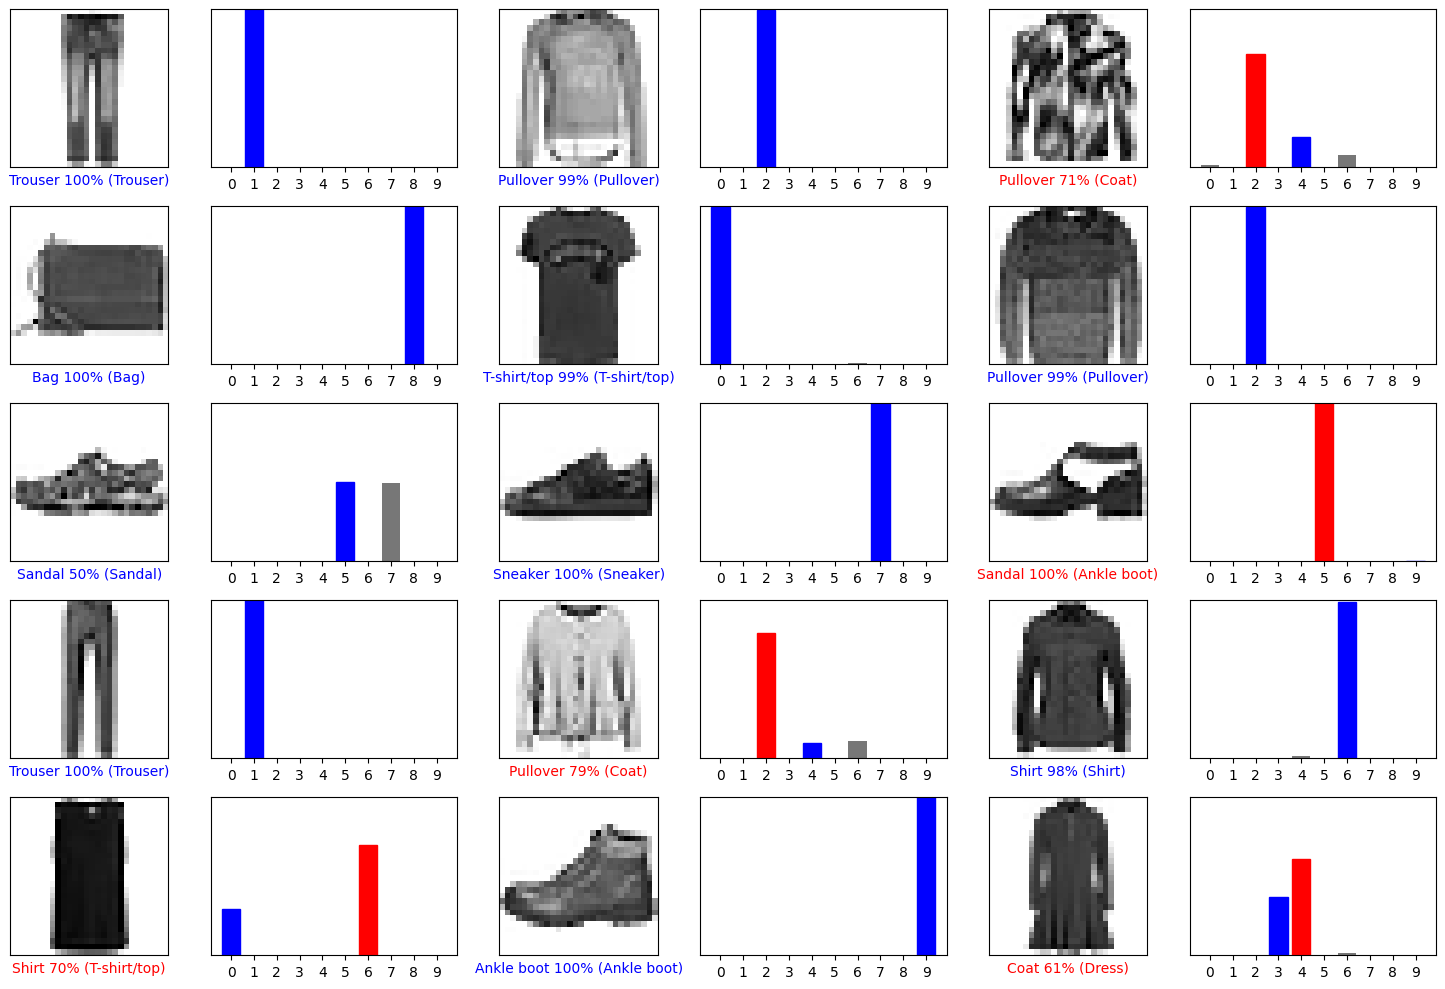

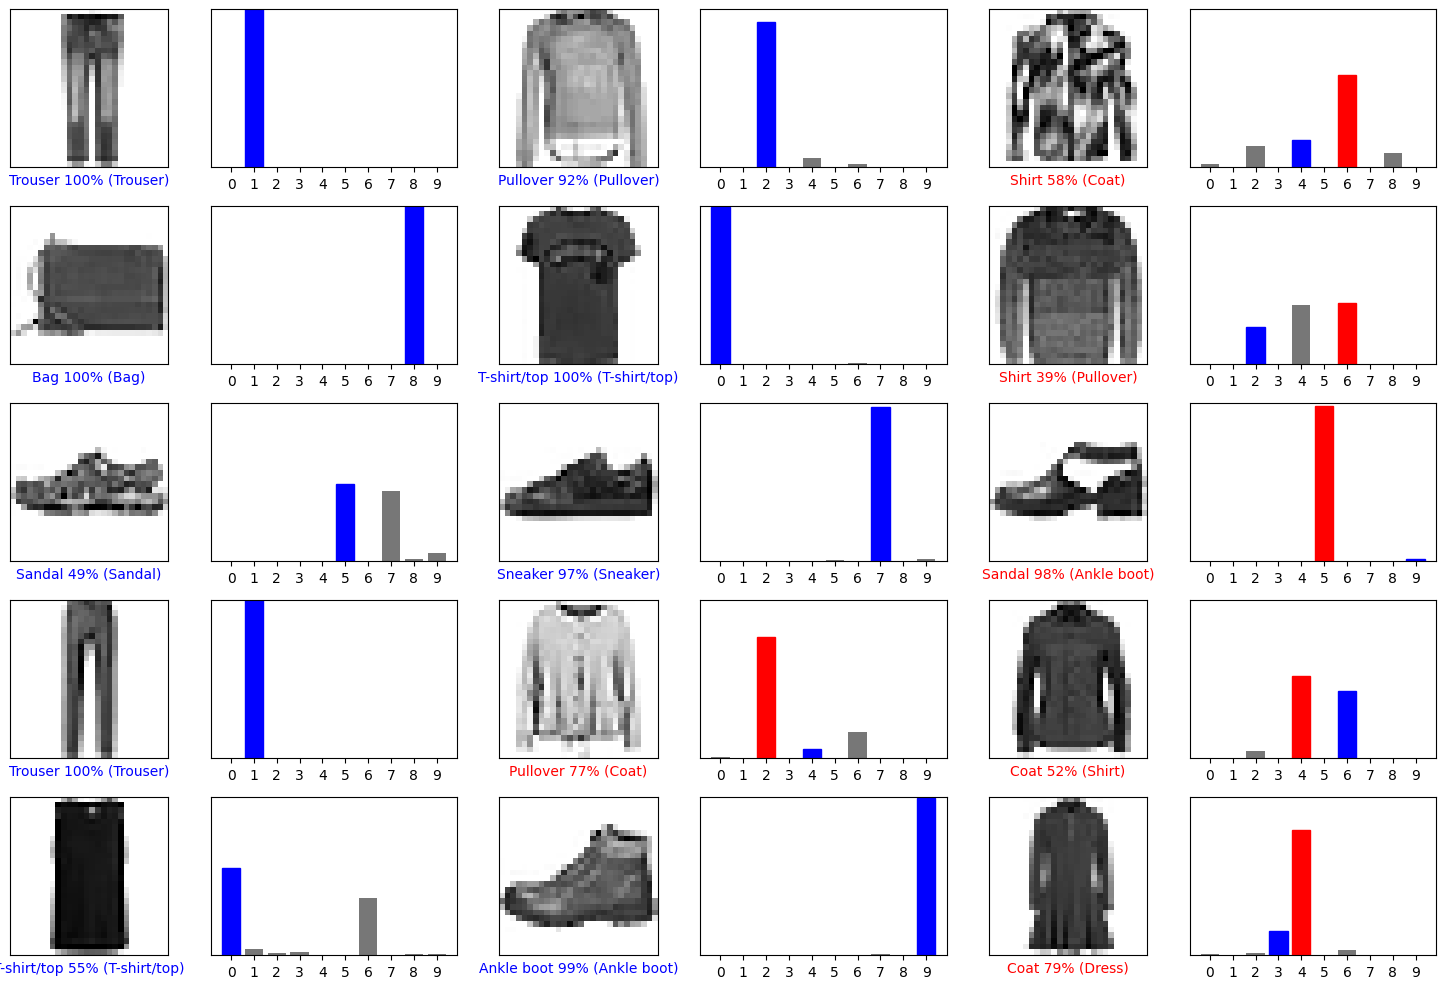

In [66]:
# Visualize 15 specific predictions
visualize_predictions(range(15, 30), predictions1)
visualize_predictions(range(15, 30), predictions2)
visualize_predictions(range(15, 30), predictions3)
visualize_predictions(range(15, 30), predictions4)